In [1]:
!pip install torchlibrosa

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchlibrosa.stft import Spectrogram, LogmelFilterBank
from torchlibrosa.augmentation import SpecAugmentation

import numpy as np
import time


def move_data_to_device(x, device):
    if 'float' in str(x.dtype):
        x = torch.Tensor(x)
    elif 'int' in str(x.dtype):
        x = torch.LongTensor(x)
    else:
        return x

    return x.to(device)


def do_mixup(x, mixup_lambda):
    """Mixup x of even indexes (0, 2, 4, ...) with x of odd indexes 
    (1, 3, 5, ...).

    Args:
      x: (batch_size * 2, ...)
      mixup_lambda: (batch_size * 2,)

    Returns:
      out: (batch_size, ...)
    """
    out = (x[0 :: 2].transpose(0, -1) * mixup_lambda[0 :: 2] + \
        x[1 :: 2].transpose(0, -1) * mixup_lambda[1 :: 2]).transpose(0, -1)
    return out
    

def append_to_dict(dict, key, value):
    if key in dict.keys():
        dict[key].append(value)
    else:
        dict[key] = [value]


def forward(model, generator, return_input=False, 
    return_target=False):
    """Forward data to a model.
    
    Args: 
      model: object
      generator: object
      return_input: bool
      return_target: bool

    Returns:
      audio_name: (audios_num,)
      clipwise_output: (audios_num, classes_num)
      (ifexist) segmentwise_output: (audios_num, segments_num, classes_num)
      (ifexist) framewise_output: (audios_num, frames_num, classes_num)
      (optional) return_input: (audios_num, segment_samples)
      (optional) return_target: (audios_num, classes_num)
    """
    output_dict = {}
    device = next(model.parameters()).device
    time1 = time.time()

    # Forward data to a model in mini-batches
    for n, batch_data_dict in enumerate(generator):
        print(n)
        batch_waveform = move_data_to_device(batch_data_dict['waveform'], device)
        
        with torch.no_grad():
            model.eval()
            batch_output = model(batch_waveform)

        append_to_dict(output_dict, 'audio_name', batch_data_dict['audio_name'])

        append_to_dict(output_dict, 'clipwise_output', 
            batch_output['clipwise_output'].data.cpu().numpy())

        if 'segmentwise_output' in batch_output.keys():
            append_to_dict(output_dict, 'segmentwise_output', 
                batch_output['segmentwise_output'].data.cpu().numpy())

        if 'framewise_output' in batch_output.keys():
            append_to_dict(output_dict, 'framewise_output', 
                batch_output['framewise_output'].data.cpu().numpy())
            
        if return_input:
            append_to_dict(output_dict, 'waveform', batch_data_dict['waveform'])
            
        if return_target:
            if 'target' in batch_data_dict.keys():
                append_to_dict(output_dict, 'target', batch_data_dict['target'])

        if n % 10 == 0:
            print(' --- Inference time: {:.3f} s / 10 iterations ---'.format(
                time.time() - time1))
            time1 = time.time()

    for key in output_dict.keys():
        output_dict[key] = np.concatenate(output_dict[key], axis=0)

    return output_dict


def interpolate(x, ratio):
    """Interpolate data in time domain. This is used to compensate the 
    resolution reduction in downsampling of a CNN.
    
    Args:
      x: (batch_size, time_steps, classes_num)
      ratio: int, ratio to interpolate

    Returns:
      upsampled: (batch_size, time_steps * ratio, classes_num)
    """
    (batch_size, time_steps, classes_num) = x.shape
    upsampled = x[:, :, None, :].repeat(1, 1, ratio, 1)
    upsampled = upsampled.reshape(batch_size, time_steps * ratio, classes_num)
    return upsampled


def pad_framewise_output(framewise_output, frames_num):
    """Pad framewise_output to the same length as input frames. The pad value 
    is the same as the value of the last frame.

    Args:
      framewise_output: (batch_size, frames_num, classes_num)
      frames_num: int, number of frames to pad

    Outputs:
      output: (batch_size, frames_num, classes_num)
    """
    pad = framewise_output[:, -1 :, :].repeat(1, frames_num - framewise_output.shape[1], 1)
    """tensor for padding"""

    output = torch.cat((framewise_output, pad), dim=1)
    """(batch_size, frames_num, classes_num)"""

    return output


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_flops(model, audio_length):
    """Count flops. Code modified from others' implementation.
    """
    multiply_adds = True
    list_conv2d=[]
    def conv2d_hook(self, input, output):
        batch_size, input_channels, input_height, input_width = input[0].size()
        output_channels, output_height, output_width = output[0].size()
 
        kernel_ops = self.kernel_size[0] * self.kernel_size[1] * (self.in_channels / self.groups) * (2 if multiply_adds else 1)
        bias_ops = 1 if self.bias is not None else 0
 
        params = output_channels * (kernel_ops + bias_ops)
        flops = batch_size * params * output_height * output_width
 
        list_conv2d.append(flops)

    list_conv1d=[]
    def conv1d_hook(self, input, output):
        batch_size, input_channels, input_length = input[0].size()
        output_channels, output_length = output[0].size()
 
        kernel_ops = self.kernel_size[0] * (self.in_channels / self.groups) * (2 if multiply_adds else 1)
        bias_ops = 1 if self.bias is not None else 0
 
        params = output_channels * (kernel_ops + bias_ops)
        flops = batch_size * params * output_length
 
        list_conv1d.append(flops)
 
    list_linear=[] 
    def linear_hook(self, input, output):
        batch_size = input[0].size(0) if input[0].dim() == 2 else 1
 
        weight_ops = self.weight.nelement() * (2 if multiply_adds else 1)
        bias_ops = self.bias.nelement()
 
        flops = batch_size * (weight_ops + bias_ops)
        list_linear.append(flops)
 
    list_bn=[] 
    def bn_hook(self, input, output):
        list_bn.append(input[0].nelement() * 2)
 
    list_relu=[] 
    def relu_hook(self, input, output):
        list_relu.append(input[0].nelement() * 2)
 
    list_pooling2d=[]
    def pooling2d_hook(self, input, output):
        batch_size, input_channels, input_height, input_width = input[0].size()
        output_channels, output_height, output_width = output[0].size()
 
        kernel_ops = self.kernel_size * self.kernel_size
        bias_ops = 0
        params = output_channels * (kernel_ops + bias_ops)
        flops = batch_size * params * output_height * output_width
 
        list_pooling2d.append(flops)

    list_pooling1d=[]
    def pooling1d_hook(self, input, output):
        batch_size, input_channels, input_length = input[0].size()
        output_channels, output_length = output[0].size()
 
        kernel_ops = self.kernel_size[0]
        bias_ops = 0
        
        params = output_channels * (kernel_ops + bias_ops)
        flops = batch_size * params * output_length
 
        list_pooling2d.append(flops)
 
    def foo(net):
        childrens = list(net.children())
        if not childrens:
            if isinstance(net, nn.Conv2d):
                net.register_forward_hook(conv2d_hook)
            elif isinstance(net, nn.Conv1d):
                net.register_forward_hook(conv1d_hook)
            elif isinstance(net, nn.Linear):
                net.register_forward_hook(linear_hook)
            elif isinstance(net, nn.BatchNorm2d) or isinstance(net, nn.BatchNorm1d):
                net.register_forward_hook(bn_hook)
            elif isinstance(net, nn.ReLU):
                net.register_forward_hook(relu_hook)
            elif isinstance(net, nn.AvgPool2d) or isinstance(net, nn.MaxPool2d):
                net.register_forward_hook(pooling2d_hook)
            elif isinstance(net, nn.AvgPool1d) or isinstance(net, nn.MaxPool1d):
                net.register_forward_hook(pooling1d_hook)
            else:
                print('Warning: flop of module {} is not counted!'.format(net))
            return
        for c in childrens:
            foo(c)

    # Register hook
    foo(model)
    
    device = device = next(model.parameters()).device
    input = torch.rand(1, audio_length).to(device)

    out = model(input)
 
    total_flops = sum(list_conv2d) + sum(list_conv1d) + sum(list_linear) + \
        sum(list_bn) + sum(list_relu) + sum(list_pooling2d) + sum(list_pooling1d)
    
    return total_flops
 

def init_layer(layer):
    """Initialize a Linear or Convolutional layer. """
    nn.init.xavier_uniform_(layer.weight)
 
    if hasattr(layer, 'bias'):
        if layer.bias is not None:
            layer.bias.data.fill_(0.)
            
    
def init_bn(bn):
    """Initialize a Batchnorm layer. """
    bn.bias.data.fill_(0.)
    bn.weight.data.fill_(1.)


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        
        super(ConvBlock, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=in_channels, 
                              out_channels=out_channels,
                              kernel_size=(3, 3), stride=(1, 1),
                              padding=(1, 1), bias=False)
                              
        self.conv2 = nn.Conv2d(in_channels=out_channels, 
                              out_channels=out_channels,
                              kernel_size=(3, 3), stride=(1, 1),
                              padding=(1, 1), bias=False)
                              
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.init_weight()
        
    def init_weight(self):
        init_layer(self.conv1)
        init_layer(self.conv2)
        init_bn(self.bn1)
        init_bn(self.bn2)

        
    def forward(self, input, pool_size=(2, 2), pool_type='avg'):
        
        x = input
        x = F.relu_(self.bn1(self.conv1(x)))
        x = F.relu_(self.bn2(self.conv2(x)))
        if pool_type == 'max':
            x = F.max_pool2d(x, kernel_size=pool_size)
        elif pool_type == 'avg':
            x = F.avg_pool2d(x, kernel_size=pool_size)
        elif pool_type == 'avg+max':
            x1 = F.avg_pool2d(x, kernel_size=pool_size)
            x2 = F.max_pool2d(x, kernel_size=pool_size)
            x = x1 + x2
        else:
            raise Exception('Incorrect argument!')
        
        return x


class ConvBlock5x5(nn.Module):
    def __init__(self, in_channels, out_channels):
        
        super(ConvBlock5x5, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=in_channels, 
                              out_channels=out_channels,
                              kernel_size=(5, 5), stride=(1, 1),
                              padding=(2, 2), bias=False)
                              
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.init_weight()
        
    def init_weight(self):
        init_layer(self.conv1)
        init_bn(self.bn1)

        
    def forward(self, input, pool_size=(2, 2), pool_type='avg'):
        
        x = input
        x = F.relu_(self.bn1(self.conv1(x)))
        if pool_type == 'max':
            x = F.max_pool2d(x, kernel_size=pool_size)
        elif pool_type == 'avg':
            x = F.avg_pool2d(x, kernel_size=pool_size)
        elif pool_type == 'avg+max':
            x1 = F.avg_pool2d(x, kernel_size=pool_size)
            x2 = F.max_pool2d(x, kernel_size=pool_size)
            x = x1 + x2
        else:
            raise Exception('Incorrect argument!')
        
        return x


class AttBlock(nn.Module):
    def __init__(self, n_in, n_out, activation='linear', temperature=1.):
        super(AttBlock, self).__init__()
        
        self.activation = activation
        self.temperature = temperature
        self.att = nn.Conv1d(in_channels=n_in, out_channels=n_out, kernel_size=1, stride=1, padding=0, bias=True)
        self.cla = nn.Conv1d(in_channels=n_in, out_channels=n_out, kernel_size=1, stride=1, padding=0, bias=True)
        
        self.bn_att = nn.BatchNorm1d(n_out)
        self.init_weights()
        
    def init_weights(self):
        init_layer(self.att)
        init_layer(self.cla)
        init_bn(self.bn_att)
         
    def forward(self, x):
        # x: (n_samples, n_in, n_time)
        norm_att = torch.softmax(torch.clamp(self.att(x), -10, 10), dim=-1)
        cla = self.nonlinear_transform(self.cla(x))
        x = torch.sum(norm_att * cla, dim=2)
        return x, norm_att, cla

    def nonlinear_transform(self, x):
        if self.activation == 'linear':
            return x
        elif self.activation == 'sigmoid':
            return torch.sigmoid(x)


class Cnn14(nn.Module):
    def __init__(self, sample_rate, window_size, hop_size, mel_bins, fmin, 
        fmax, classes_num):
        
        super(Cnn14, self).__init__()

        window = 'hann'
        center = True
        pad_mode = 'reflect'
        ref = 1.0
        amin = 1e-10
        top_db = None

        # Spectrogram extractor
        self.spectrogram_extractor = Spectrogram(n_fft=window_size, hop_length=hop_size, 
            win_length=window_size, window=window, center=center, pad_mode=pad_mode, 
            freeze_parameters=True)

        # Logmel feature extractor
        self.logmel_extractor = LogmelFilterBank(sr=sample_rate, n_fft=window_size, 
            n_mels=mel_bins, fmin=fmin, fmax=fmax, ref=ref, amin=amin, top_db=top_db, 
            freeze_parameters=True)

        # Spec augmenter
        self.spec_augmenter = SpecAugmentation(time_drop_width=64, time_stripes_num=2, 
            freq_drop_width=8, freq_stripes_num=2)

        self.bn0 = nn.BatchNorm2d(64)

        self.conv_block1 = ConvBlock(in_channels=1, out_channels=64)
        self.conv_block2 = ConvBlock(in_channels=64, out_channels=128)
        self.conv_block3 = ConvBlock(in_channels=128, out_channels=256)
        self.conv_block4 = ConvBlock(in_channels=256, out_channels=512)
        self.conv_block5 = ConvBlock(in_channels=512, out_channels=1024)
        self.conv_block6 = ConvBlock(in_channels=1024, out_channels=2048)

        self.fc1 = nn.Linear(2048, 2048, bias=True)
        self.fc_audioset = nn.Linear(2048, classes_num, bias=True)
        
        self.init_weight()

    def init_weight(self):
        init_bn(self.bn0)
        init_layer(self.fc1)
        init_layer(self.fc_audioset)
 
    def forward(self, input, mixup_lambda=None):
        """
        Input: (batch_size, data_length)"""

        x = self.spectrogram_extractor(input)   # (batch_size, 1, time_steps, freq_bins)
        x = self.logmel_extractor(x)    # (batch_size, 1, time_steps, mel_bins)

        x = x.transpose(1, 3)
        x = self.bn0(x)
        x = x.transpose(1, 3)
        
        if self.training:
            x = self.spec_augmenter(x)

        # Mixup on spectrogram
        if self.training and mixup_lambda is not None:
            x = do_mixup(x, mixup_lambda)

        x = self.conv_block1(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv_block2(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv_block3(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv_block4(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv_block5(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv_block6(x, pool_size=(1, 1), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = torch.mean(x, dim=3)
        
        (x1, _) = torch.max(x, dim=2)
        x2 = torch.mean(x, dim=2)
        x = x1 + x2
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu_(self.fc1(x))
        embedding = F.dropout(x, p=0.5, training=self.training)
        clipwise_output = torch.sigmoid(self.fc_audioset(x))
        
        output_dict = {'clipwise_output': clipwise_output, 'embedding': embedding}

        return output_dict

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

import warnings
warnings.filterwarnings("ignore")

import torchaudio

import IPython

from torchaudio import transforms

from torch.utils.data import Dataset, DataLoader
# from torchaudio.utils import download_asset

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import seaborn as sns

from copy import deepcopy

import torch.nn.functional as F
import math

import random

def create_df(path):
    dd = {"audios": [], "labels": []}
    for i in os.listdir(path):
        img_dir = os.path.join(path, i)
        dirs = os.listdir(img_dir)
        index = 0
        for j in dirs:
            dd["audios"] += [os.path.join(img_dir, j)]
            dd["labels"] += [i]
            index += 1
            # if index == 50:
            #     break

    return pd.DataFrame(dd)

neg = create_df("/kaggle/input/datasets/a3amat02/infant-cry-detection-dataset/negative")
pos = create_df("/kaggle/input/datasets/a3amat02/infant-cry-detection-dataset/positive")
df = pd.concat([pos, neg])

index_label = {0: "negative", 1: "positive"}
label_index = {"negative": 0, "positive": 1}

df["labels"] = df["labels"].map(label_index)

In [4]:
class AudioUtil():
    # ----------------------------
    # Load an audio file. Return the signal as a tensor and the sample rate
    # ----------------------------
    @staticmethod
    def open(audio_file):
        sig, sr = torchaudio.load(audio_file)
        return (sig, sr)
    
    
    # ----------------------------
    # Convert the given audio to the desired number of channels
    # ----------------------------
    @staticmethod
    def rechannel(aud, new_channel):
        sig, sr = aud

        if (sig.shape[0] == new_channel):
            # Nothing to do
            return aud

        if (new_channel == 1):
            # Convert from stereo to mono by selecting only the first channel
            # resig = sig[:1, :]
            resig = np.average()
        else:
            # Convert from mono to stereo by duplicating the first channel
            resig = torch.cat([sig, sig])

        return ((resig, sr))
    
    
    # ----------------------------
    # Since Resample applies to a single channel, we resample one channel at a time
    # ----------------------------
    @staticmethod
    def resample(aud, newsr):
        sig, sr = aud

        if (sr == newsr):
            # Nothing to do
            return aud

        num_channels = sig.shape[0]
        # Resample first channel
        resig = torchaudio.transforms.Resample(sr, newsr)(sig[:1,:])
        if (num_channels > 1):
            # Resample the second channel and merge both channels
            retwo = torchaudio.transforms.Resample(sr, newsr)(sig[1:,:])
            resig = torch.cat([resig, retwo])

        return ((resig, newsr))
    
    
    # ----------------------------
    # Pad (or truncate) the signal to a fixed length 'max_ms' in milliseconds
    # ----------------------------
    @staticmethod
    def pad_trunc(aud, max_ms):
        sig, sr = aud
        num_rows, sig_len = sig.shape
        max_len = sr//1000 * max_ms

        if (sig_len > max_len):
            # Truncate the signal to the given length
            sig = sig[:,:max_len]

        elif (sig_len < max_len):
            # Length of padding to add at the beginning and end of the signal
            pad_begin_len = random.randint(0, max_len - sig_len)
            pad_end_len = max_len - sig_len - pad_begin_len

            # Pad with 0s
            pad_begin = torch.zeros((num_rows, pad_begin_len))
            pad_end = torch.zeros((num_rows, pad_end_len))

            sig = torch.cat((pad_begin, sig, pad_end), 1)

        return (sig, sr)

In [5]:
# ----------------------------
# Sound Dataset
# ----------------------------
class SoundDS(Dataset):
    def __init__(self, df):
        self.df = df
        # self.duration = 112800
        self.duration = 4000
        self.sr = 16000
        self.channel = 1
        self.shift_pct = 0.4

    # ----------------------------
    # Number of items in dataset
    # ----------------------------
    def __len__(self):
        return len(self.df)    

    # ----------------------------
    # Get i'th item in dataset
    # ----------------------------
    def __getitem__(self, idx):
        # Absolute file path of the audio file - concatenate the audio directory with
        # the relative path
        audio_file = self.df[idx, 0]
        # Get the Class ID
        class_id = self.df[idx,-1]

        aud = AudioUtil.open(audio_file)
        # Some sounds have a higher sample rate, or fewer channels compared to the
        # majority. So make all sounds have the same number of channels and same 
        # sample rate. Unless the sample rate is the same, the pad_trunc will still
        # result in arrays of different lengths, even though the sound duration is
        # the same.
        reaud = AudioUtil.resample(aud, self.sr)
        rechan = AudioUtil.rechannel(reaud, self.channel)

        dur_aud, _ = AudioUtil.pad_trunc(rechan, self.duration)

        return dur_aud, class_id

In [6]:
PANN = Cnn14(sample_rate=16000, window_size=1024, hop_size=320,
              mel_bins=64, fmin=50, fmax=14000, classes_num=527)

checkpoint = torch.load("/kaggle/input/models/a3amat02/cnn14-pre-trained/pytorch/default/1/Cnn14_mAP0.431.pth", map_location="cpu")
PANN.load_state_dict(checkpoint["model"])

for block_name in ["conv_block1", "conv_block2", "conv_block3"]:
    block = getattr(PANN, block_name)
    for param in block.parameters():
        param.requires_grad = False

In [7]:
class Cnn14Frontend(nn.Module):
    def __init__(self, pretrained_model, cutoff_block=4):
        super().__init__()
        self.pre_trained_model = pretrained_model
        self.spectrogram_extractor = self.pre_trained_model.spectrogram_extractor
        self.logmel_extractor = self.pre_trained_model.logmel_extractor
        self.spec_augmenter = self.pre_trained_model.spec_augmenter
        self.bn0 = self.pre_trained_model.bn0
        self.blocks = nn.ModuleList([
            getattr(self.pre_trained_model, f"conv_block{i}") for i in range(1, cutoff_block + 1)
        ])

    def forward(self, waveform, is_training=True):
        x = self.spectrogram_extractor(waveform)
        x = self.logmel_extractor(x)
        x = x.transpose(1, 3)
        x = self.bn0(x)
        x = x.transpose(1, 3)
        if is_training:
            x = self.spec_augmenter(x)
        for block in self.blocks:
            x = block(x, pool_size=(2, 2), pool_type="avg")
        return x  # shape: (B, C, F', T') — feed this into CBAM

In [8]:
class SAM(nn.Module):
    def __init__(self, bias=False):
        super(SAM, self).__init__()
        self.bias = bias
        self.conv = nn.Conv1d(in_channels=2, out_channels=1, kernel_size=7, stride=1, padding=3, dilation=1, bias=self.bias)

    def forward(self, x):
        max_val = torch.max(x,1)[0].unsqueeze(1)
        avg = torch.mean(x,1).unsqueeze(1)
        concat = torch.cat((max_val,avg), dim=1)
        output = self.conv(concat)
        output = F.sigmoid(output) * x 
        return output 

class CAM(nn.Module):
    def __init__(self, channels, r):
        super(CAM, self).__init__()
        self.channels = channels
        self.r = r
        self.linear = nn.Sequential(
            nn.Linear(in_features=self.channels, out_features=self.channels//self.r, bias=True),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=self.channels//self.r, out_features=self.channels, bias=True))

    def forward(self, x):
        max_pool = F.adaptive_max_pool1d(x, output_size=1)
        # print(max_pool.shape)
        avg = F.adaptive_avg_pool1d(x, output_size=1)
        # print(avg.shape)
        b, c, _ = x.size()
        linear_max = self.linear(max_pool.view(b,c)).view(b, c, 1)
        linear_avg = self.linear(avg.view(b,c)).view(b, c, 1)
        output = linear_max + linear_avg
        output = F.sigmoid(output) * x
        return output
    
class CBAM(nn.Module):
    def __init__(self, channels, r):
        super(CBAM, self).__init__()
        self.channels = channels
        self.r = r
        self.sam = SAM(bias=False)
        self.cam = CAM(channels=self.channels, r=self.r)

    def forward(self, x):
        output = self.cam(x)
        output = self.sam(output)
        return output + x

In [9]:
class EncoderBlock(nn.Module):

    def __init__(self, cbam_channels, r, input_dim, num_heads, dim_feedforward, dropout=0.0):
        """
        Inputs:
            input_dim - Dimensionality of the input
            num_heads - Number of heads to use in the attention block
            dim_feedforward - Dimensionality of the hidden layer in the MLP
            dropout - Dropout probability to use in the dropout layers
        """
        super().__init__()

        # Attention layer
        self.self_attn = nn.MultiheadAttention(input_dim, num_heads)

        # CBAM layer

        self.cbam = CBAM(cbam_channels, r)

        # Two-layer MLP
        self.linear_net = nn.Sequential(
            nn.Linear(input_dim, dim_feedforward),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Linear(dim_feedforward, input_dim)
        )

        # Layers to apply in between the main layers
        self.norm1 = nn.LayerNorm(input_dim)
        self.norm2 = nn.LayerNorm(input_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Attention part
        attn_out, _ = self.self_attn(x, x, x)
        x = x + self.dropout(attn_out)
        x = self.norm1(x)

        #CBAM part

        x = x.transpose(1, 2)
        x = self.cbam(x)
        x = x.transpose(1, 2)

        # MLP part
        linear_out = self.linear_net(x)
        x = x + self.dropout(linear_out)
        x = self.norm2(x)

        return x

class TransformerEncoder(nn.Module):

    def __init__(self, num_layers, **block_args):
        super().__init__()
        self.layers = nn.ModuleList([EncoderBlock(**block_args) for _ in range(num_layers)])

    def forward(self, x, mask=None):
        for l in self.layers:
            x = l(x, mask=mask)
        return x

    def get_attention_maps(self, x, mask=None):
        attention_maps = []
        for l in self.layers:
            _, attn_map = l.self_attn(x, mask=mask, return_attention=True)
            attention_maps.append(attn_map)
            x = l(x)
        return attention_maps

In [10]:
class PANN_Transformer_CBAM_Gate(nn.Module):
    def __init__(self, pre_trained_model, cbam_channels, r, num_layers, input_dim, num_heads, dim_feedforward, out_dim, num_classes, dropout=0.0):
        super().__init__()
        self.pann = Cnn14Frontend(pre_trained_model)
        self.encoder = TransformerEncoder(num_layers=num_layers, cbam_channels=cbam_channels, r = r,
                                          input_dim=input_dim, num_heads=num_heads, dim_feedforward=dim_feedforward, dropout=dropout)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, waveform, is_training=True):
        waveform = torch.flatten(waveform, start_dim=1)
        x = self.pann(waveform, is_training)
        x = x.mean(dim=3)
        x = x.transpose(1, 2)
        x = self.encoder(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x

In [11]:
# class DummyModel(nn.Module):
#     def __init__(self, pre_trained_model, input_channels, r):
#         super().__init__()
#         self.pann = Cnn14Frontend(pre_trained_model)
#         self.cbam = CBAM(input_channels, r)

#     def forward(self, waveform):
#         waveform = torch.flatten(waveform, start_dim=1)
#         x = self.pann(waveform)
#         x = x.mean(dim=3)
#         x = self.cbam(x)
#         # x = x.mean(dim=3)
#         # x = x.transpose(1, 2)
#         return x

In [12]:
EPOCHS = 20
STEP = 10
LR = 0.1
GAMMA = 0.1
IMG_SIZE = 224
BATCH = 16
OUT_SIZE = len(index_label)

train, val = train_test_split(df.values, random_state=42, test_size=0.25)
test, val = train_test_split(val, random_state=42, test_size=0.5)

train_ds = SoundDS(train)
val_ds = SoundDS(val)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False)

In [13]:
model = PANN_Transformer_CBAM_Gate(PANN, 512, 16, 8, 512, 8, 1024, 6144, OUT_SIZE, 0.25)
# model = DummyModel(PANN, 512, 2)
# model = model.to("cpu")

In [14]:
from sklearn.utils.class_weight import compute_class_weight

device = "cuda" if torch.cuda.is_available() else "cpu"

optimizer = torch.optim.AdamW([
    {"params": model.pann.blocks[3:].parameters(), "lr": 1e-5},
    {"params": model.encoder.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-4},
])

if torch.cuda.device_count() > 1:
  print("Let's use", torch.cuda.device_count(), "GPUs!")
  # dim = 0 [30, xxx] -> [10, ...], [10, ...], [10, ...] on 3 GPUs
  model = nn.DataParallel(model)

model.to(device)

# integer labels for your training set, using your existing label2id mapping
train_labels = train[:, -1]

class_ids = np.arange(OUT_SIZE)  # [0, 1, ..., num_classes-1], in id2label order
weights = compute_class_weight(class_weight="balanced", classes=class_ids, y=train_labels)

class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
# optimizer = torch.optim.AdamW([
#     {"params": model.pann.pre_trained_model[3:].parameters(), "lr": 1e-5},   # fine-tuned pretrained blocks
#     {"params": model.cbam.parameters(), "lr": 1e-4},
#     {"params": model.encoder.parameters(), "lr": 1e-4},
#     {"params": model.fc.parameters(), "lr": 1e-4},
# ])

warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS-3)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[3])

Let's use 2 GPUs!


Epoch 1 train loss 0.014342270963946073 acc 0.9066860192901958 val loss 0.00709094466910347 acc 0.9648876404494382
Epoch 2 train loss 0.007759303176179032 acc 0.9534600618035397 val loss 0.0064728286607476735 acc 0.9629213483146067
Epoch 3 train loss 0.0059938927441609635 acc 0.9657739488716172 val loss 0.007801580567610181 acc 0.9452247191011236
Epoch 4 train loss 0.005423485147896209 acc 0.9701282891656522 val loss 0.0054057590313073235 acc 0.9654494382022472
Epoch 5 train loss 0.004431192431811936 acc 0.9762150014046259 val loss 0.0018545221113138754 acc 0.9907303370786517
Epoch 6 train loss 0.003888635206939576 acc 0.977713269032681 val loss 0.004436441395227535 acc 0.9808988764044944
Epoch 7 train loss 0.003298781148656924 acc 0.9824889970971065 val loss 0.0013891870874019538 acc 0.9912921348314607
Epoch 8 train loss 0.0029984193148810782 acc 0.9839404438617848 val loss 0.0020040261356582454 acc 0.9904494382022472
Epoch 9 train loss 0.002625577494219576 acc 0.9856728158067235 val 

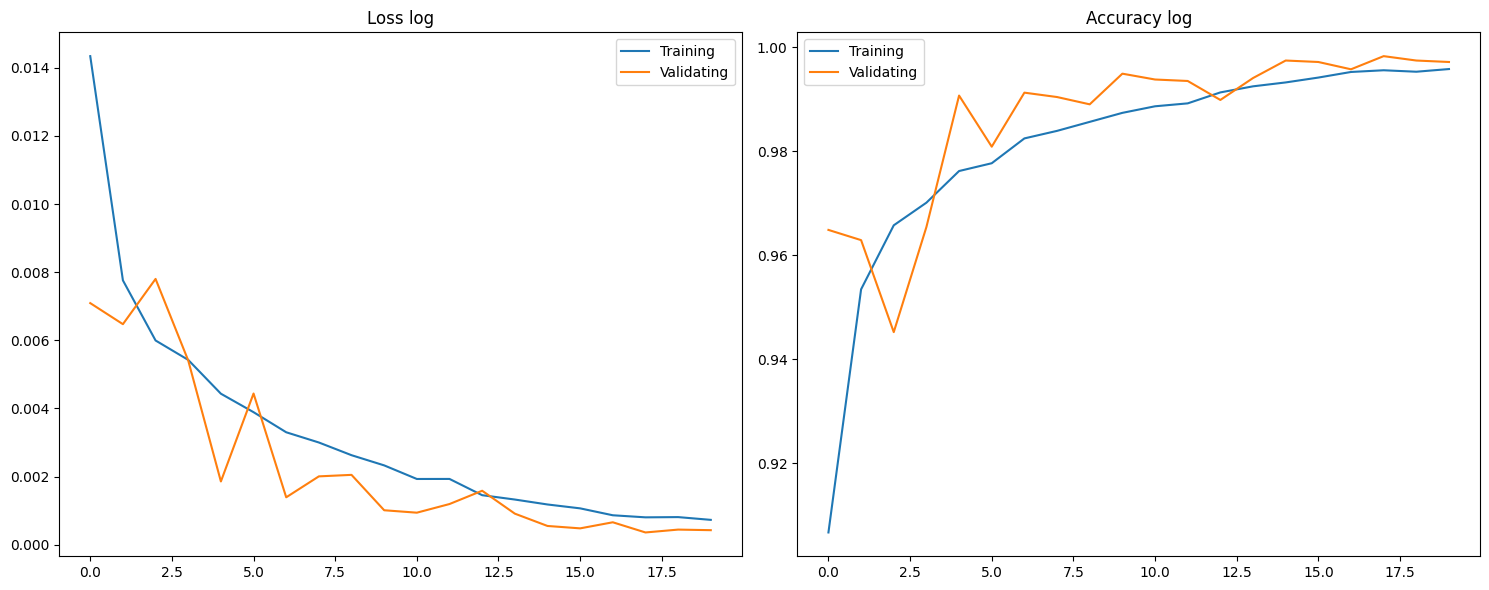

In [15]:
best_model = deepcopy(model)
best_acc = 0

train_loss = []
train_acc = []
val_loss = []
val_acc = []

for i in range(1, EPOCHS+1):
    model.train()

    diff = 0
    acc = 0
    total = 0

    for data, target in train_dl:
        optimizer.zero_grad()
        if torch.cuda.is_available():
            data, target = data.to(device), target.to(device)
        # print(data.shape)
        out = model(data)
        loss = criterion(out, target)
        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)

        loss.backward()
        optimizer.step()

    train_loss += [diff/total]
    train_acc += [acc/total]

    model.eval()

    diff = 0
    acc = 0
    total = 0

    with torch.no_grad():
        for data, target in val_dl:
            optimizer.zero_grad()
            if torch.cuda.is_available():
                data, target = data.to(device), target.to(device)

            out = model(data, False)
            loss = criterion(out, target)
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)

    val_loss += [diff/total]
    val_acc += [acc/total]

    if val_acc[-1] >= best_acc:
        best_acc = val_acc[-1]
        best_model = deepcopy(model)

    scheduler.step()

    print("Epoch {} train loss {} acc {} val loss {} acc {}".format(i, train_loss[-1], train_acc[-1],
                                                                   val_loss[-1], val_acc[-1]))

fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

index = 0

axes[index].plot(train_loss, label="Training")
axes[index].plot(val_loss, label="Validating")
axes[index].set_title("Loss log")
axes[index].legend()

index += 1

axes[index].plot(train_acc, label="Training")
axes[index].plot(val_acc, label="Validating")
axes[index].set_title("Accuracy log")
axes[index].legend()
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1940
           1       0.94      0.98      0.96      1620

    accuracy                           0.97      3560
   macro avg       0.96      0.97      0.97      3560
weighted avg       0.97      0.97      0.97      3560



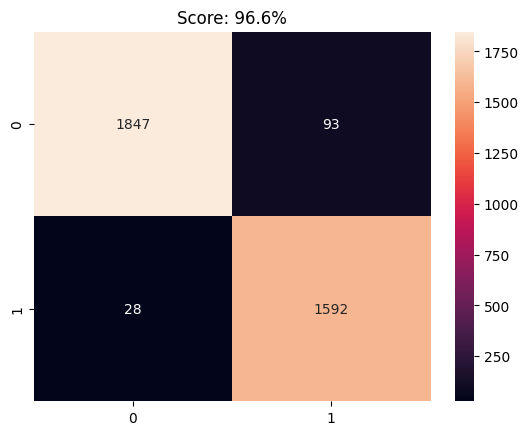

In [16]:
def predict(img):
    aud = AudioUtil.open(img)
    reaud = AudioUtil.resample(aud, 16000)
    rechan = AudioUtil.rechannel(reaud, 1)

    dur_aud, _ = AudioUtil.pad_trunc(rechan, 4000)

    best_model.eval()
    with torch.no_grad():
        if torch.cuda.is_available():
            dur_aud = dur_aud.cuda()
        out = best_model(dur_aud, False)

    out = F.softmax(out, dim=1)

    index = out.argmax(1).item()

    return index, round(out[0][index].item()*100, 2)

truth = []
preds = []
probas = []

np.random.shuffle(test)

for i in range(test.shape[0]):
    truth += [test[i, 1]]
    pred, proba = predict(test[i, 0])
    preds += [pred]
    probas += [proba]

score = accuracy_score(preds, truth)
print(classification_report(preds, truth))
sns.heatmap(confusion_matrix(preds, truth), annot=True, fmt='d')
plt.title("Score: {}%".format(round(score*100, 2)))
plt.show()

In [17]:
import json

# unwrap DataParallel if it was used, so the saved keys don't have a "module." prefix
model_to_save = best_model.module if isinstance(best_model, nn.DataParallel) else best_model

torch.save(model_to_save.state_dict(), "best_pann_transformer_cbam_gate_infant_cry.pth")

# Save the architecture config alongside the weights — critical, since you've been
# tuning r, num_layers, out_dim, etc. and need to reconstruct the exact same shapes later

config = {
    "dim_feedforward": 1024,
    "num_classes": OUT_SIZE,
    "out_dim": 6144,
    "cbam_channels": 512,
    "r": 16,
    "num_layers": 8,
    "input_dim": 512,
    "dropout": 0.25
}
with open("best_pann_transformer_cbam_gate_infant_cry_config.json", "w") as f:
    json.dump(config, f, indent=2)